In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data

In [3]:
airline_financials = pd.read_csv("data/airline_financials.csv")
aviation_incidents = pd.read_csv("data/aviation_incidents.csv")
fleet_orders = pd.read_csv("data/fleet_orders.csv")
passenger_traffic = pd.read_csv("data/passenger_traffic.csv")
route_performance = pd.read_csv("data/route_performance.csv")

# 2. Review the data

### 2.1 airline_financials 

In [4]:
airline_financials.head()

,year,airline_name,iata_code,country_iso3,region,business_model,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,passengers_carried_m,load_factor_pct,fleet_size_est
0,2010,Delta Air Lines,DAL,USA,North America,legacy,32.09,3.4,1.09,48.1,84.5,160
1,2011,Delta Air Lines,DAL,USA,North America,legacy,34.54,1.1,0.39,51.8,80.4,172
2,2012,Delta Air Lines,DAL,USA,North America,legacy,35.50,5.2,1.85,53.2,83.0,177
3,2013,Delta Air Lines,DAL,USA,North America,legacy,36.20,8.2,2.97,54.3,84.6,181
4,2014,Delta Air Lines,DAL,USA,North America,legacy,39.00,8.8,3.44,58.5,83.9,194


In [5]:
airline_financials.dtypes

year                         int64
airline_name                object
iata_code                   object
country_iso3                object
region                      object
business_model              object
revenue_usd_bn             float64
operating_margin_pct       float64
operating_income_usd_bn    float64
passengers_carried_m       float64
load_factor_pct            float64
fleet_size_est               int64
dtype: object

In [6]:
airline_financials.shape

(497, 12)

In [7]:
airline_financials.isna().sum()

year                       0
airline_name               0
iata_code                  0
country_iso3               0
region                     0
business_model             0
revenue_usd_bn             0
operating_margin_pct       0
operating_income_usd_bn    0
passengers_carried_m       0
load_factor_pct            0
fleet_size_est             0
dtype: int64

### 2.2 aviation_incidents

In [8]:
aviation_incidents.head()

,incident_id,date,year,month,flight_number,airline,aircraft_type,severity,fatalities,location,description,is_fatal,is_geopolitical,is_boeing,is_airbus
0,AV001,2010-04-10,2010,4,PLF101,Polish AF,Tu-154,fatal_crash,96,"Smolensk, Russia",Polish presidential plane crash,1,0,0,0
1,AV002,2010-05-22,2010,5,IX812,Air India Express,B737-800,fatal_crash,158,"Mangalore, India",Runway overrun,1,0,1,0
2,AV003,2011-07-08,2011,7,PIA8264,Hewa Bora Airways,B727,fatal_crash,81,"Kisangani, DRC",Severe weather landing,1,0,1,0
3,AV004,2012-04-20,2012,4,BSC213,Bhoja Air,B737-200,fatal_crash,127,"Islamabad, Pakistan",Crashed near airport,1,0,1,0
4,AV005,2013-07-06,2013,7,OZ214,Asiana Airlines,B777-200,fatal_crash,3,"San Francisco, USA",Hard landing short of runway,1,0,1,0


In [9]:
aviation_incidents.dtypes

incident_id        object
date               object
year                int64
month               int64
flight_number      object
airline            object
aircraft_type      object
severity           object
fatalities          int64
location           object
description        object
is_fatal            int64
is_geopolitical     int64
is_boeing           int64
is_airbus           int64
dtype: object

In [10]:
aviation_incidents.shape

(40, 15)

### 2.3 fleet_orders

In [11]:
fleet_orders.head()

,year,manufacturer,aircraft_family,orders_gross,orders_net,deliveries,backlog_end_of_year,is_widebody,is_narrowbody,is_regional
0,2010,Airbus,A320 family,452,452,401,2440,0,1,0
1,2010,Airbus,A330/340/350/380,122,122,109,776,1,0,0
2,2010,Boeing,737,506,506,376,2079,0,1,0
3,2010,Boeing,747/767/777/787,24,24,86,1057,1,0,0
4,2011,Airbus,A320 family,719,719,431,3061,0,1,0


In [12]:
fleet_orders.dtypes

year                    int64
manufacturer           object
aircraft_family        object
orders_gross            int64
orders_net              int64
deliveries              int64
backlog_end_of_year     int64
is_widebody             int64
is_narrowbody           int64
is_regional             int64
dtype: object

In [13]:
fleet_orders.shape

(86, 10)

### 2.4 passenger_traffic

In [14]:
passenger_traffic.head()

,year_month,year,month,region,rpk_billions,ask_billions,load_factor_pct
0,2010-01,2010,1,North America,61.73,76.45,80.8
1,2010-02,2010,2,North America,58.63,72.13,81.3
2,2010-03,2010,3,North America,60.16,72.79,82.6
3,2010-04,2010,4,North America,64.07,76.80,83.4
4,2010-05,2010,5,North America,69.43,85.85,80.9


In [15]:
passenger_traffic.dtypes

year_month          object
year                 int64
month                int64
region              object
rpk_billions       float64
ask_billions       float64
load_factor_pct    float64
dtype: object

In [16]:
passenger_traffic.shape

(1176, 7)

### 2.5 route_performance

In [17]:
route_performance.head()

,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
0,2015,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",6.37,50.0,19,320.5
1,2018,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.92,68.0,22,539.4
2,2019,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.65,65.0,21,498.0
3,2020,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",2.21,21.0,4,45.4
4,2021,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",3.57,34.0,10,121.5


In [18]:
route_performance.dtypes

year                      int64
route                    object
origin_iata              object
destination_iata         object
distance_km               int64
region                   object
main_airlines            object
annual_passengers_m     float64
avg_fare_usd            float64
weekly_frequency_est      int64
annual_revenue_usd_m    float64
dtype: object

In [19]:
route_performance.shape

(400, 11)

# 3. Explanatory Data Analysis(EDA)

### 3.1 Statistical Analysis

### 3.1 Statistical Analysis

In [20]:
def statistical_summary(df: pd.DataFrame, name: str):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Shape: {df.shape}")

    print("\n--- Dtypes ---")
    print(df.dtypes)

    print("\n--- Missing values ---")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    print(pd.DataFrame({"missing": missing, "pct": missing_pct})[missing > 0])

    print("\n--- Duplicates ---")
    print(f"{df.duplicated().sum()} duplicate rows")

    print("\n--- Numeric summary ---")
    print(df.describe().T)

    print("\n--- Categorical summary ---")
    cat_cols = df.select_dtypes(include="object").columns
    for col in cat_cols:
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(df[col].value_counts().head(10))

    if "year" in df.columns:
        print(f"\n--- Year range ---")
        print(f"{df['year'].min()} to {df['year'].max()}, {df['year'].nunique()} unique years")


for name, df in {
    "airline_financials": airline_financials,
    "fleet_orders": fleet_orders,
    "passenger_traffic": passenger_traffic,
    "aviation_incidents": aviation_incidents,
    "route_performance": route_performance,
}.items():
    statistical_summary(df, name)


airline_financials
Shape: (497, 12)

--- Dtypes ---
year                         int64
airline_name                object
iata_code                   object
country_iso3                object
region                      object
business_model              object
revenue_usd_bn             float64
operating_margin_pct       float64
operating_income_usd_bn    float64
passengers_carried_m       float64
load_factor_pct            float64
fleet_size_est               int64
dtype: object

--- Missing values ---
Empty DataFrame
Columns: [missing, pct]
Index: []

--- Duplicates ---
0 duplicate rows

--- Numeric summary ---
                         count         mean        std      min      25%  \
year                     497.0  2018.052314   4.919645  2010.00  2014.00   
revenue_usd_bn           497.0    15.716801  12.984107     0.01     6.30   
operating_margin_pct     497.0     3.261972  11.953650   -44.10     3.50   
operating_income_usd_bn  497.0     0.732072   1.535272    -6.57     0.28 

In [21]:
import os

def eda_charts(df: pd.DataFrame, name: str, out_dir: str = "charts"):
    os.makedirs(out_dir, exist_ok=True)

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    if "year" in numeric_cols:
        numeric_cols.remove("year")

    n_cols = 3
    n_rows = -(-len(numeric_cols) // n_cols)  # ceil division

    # Distributions
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(f"{name} — Distributions")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_distributions.png", dpi=150)
    plt.show()
    plt.close(fig)

    # Outliers
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(f"{name} — Outliers")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_outliers.png", dpi=150)
    plt.show()
    plt.close(fig)

    # Correlations
    if len(numeric_cols) > 1:
        fig = plt.figure(figsize=(8, 6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
        plt.title(f"{name} — Correlations")
        plt.savefig(f"{out_dir}/{name}_correlations.png", dpi=150)
        plt.show()
        plt.close(fig)

    # Yearly trend
    if "year" in df.columns:
        fig = plt.figure(figsize=(10, 4))
        yearly = df.groupby("year")[numeric_cols].mean()
        yearly.plot(ax=plt.gca())
        plt.title(f"{name} — Yearly Trend")
        plt.axvspan(2020, 2021, color="red", alpha=0.1, label="COVID")
        plt.legend()
        plt.savefig(f"{out_dir}/{name}_yearly_trend.png", dpi=150)
        plt.show()
    plt.show()

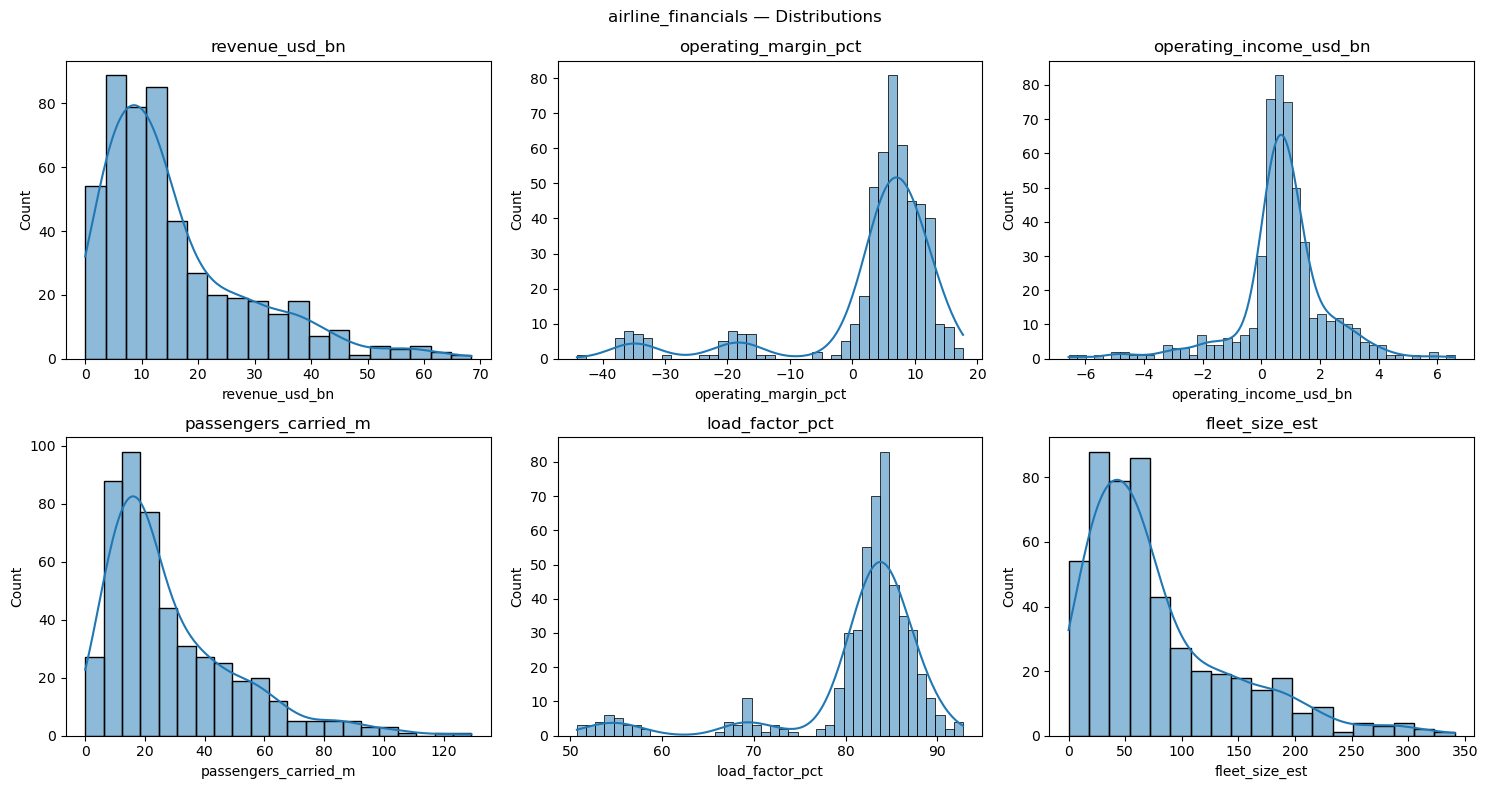

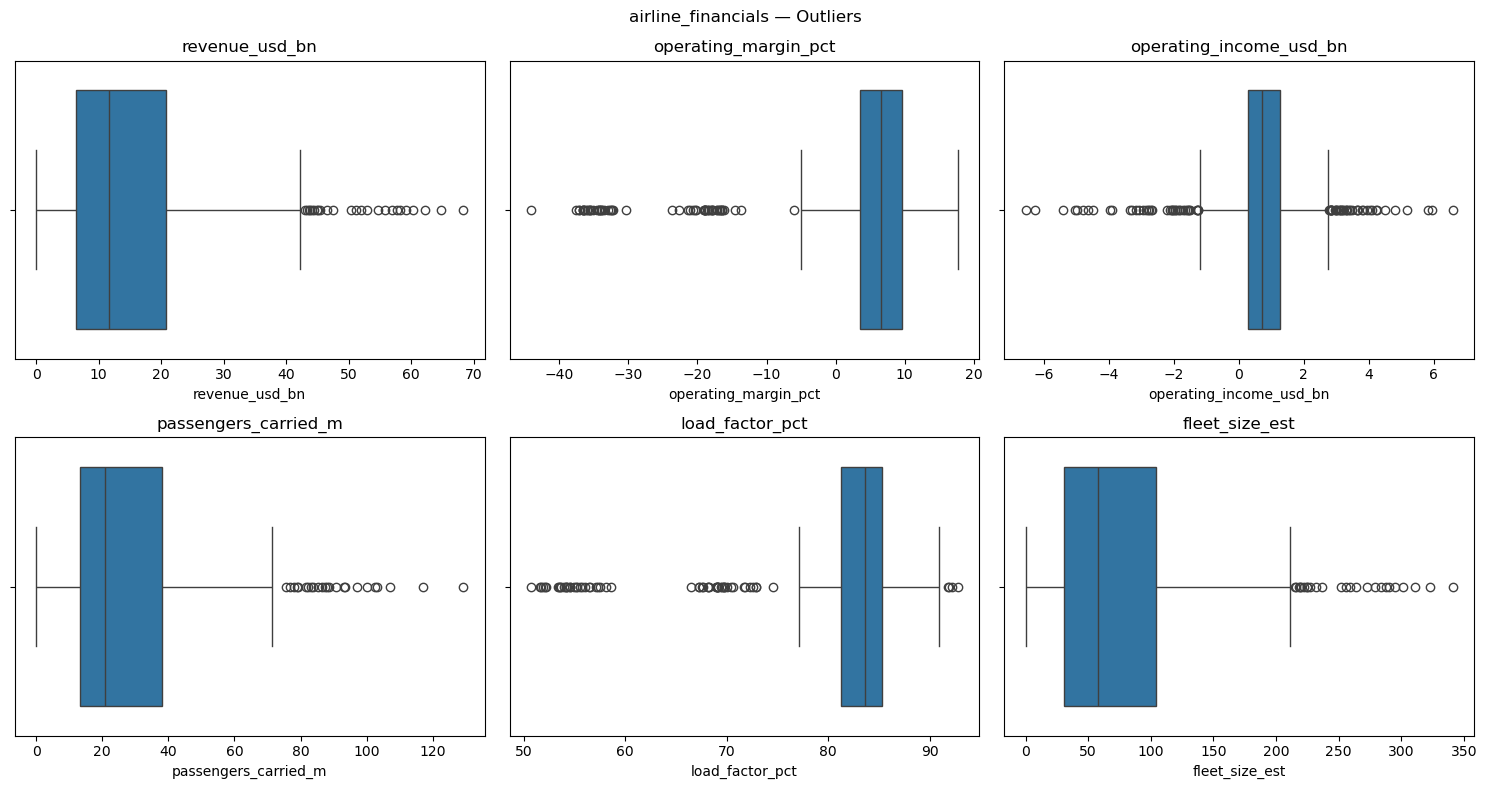

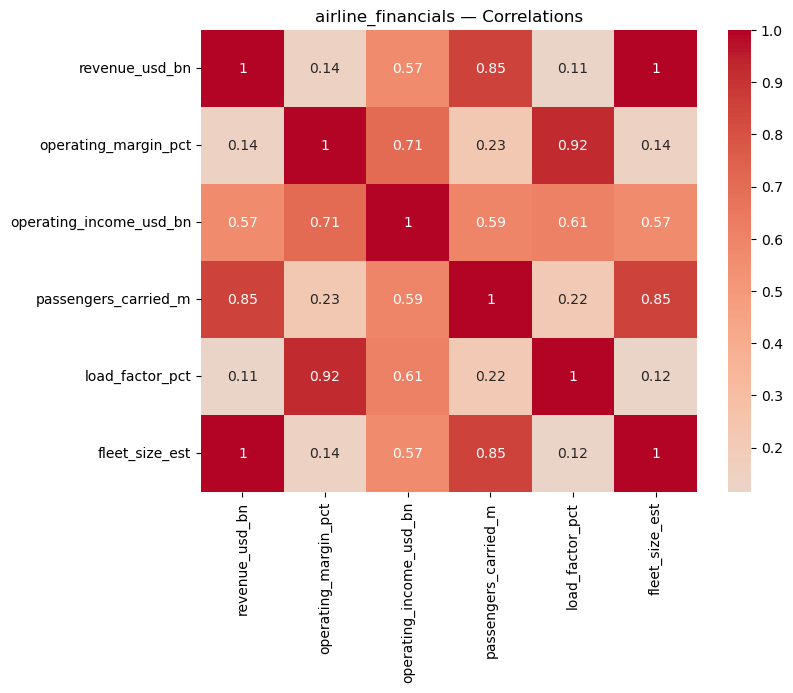

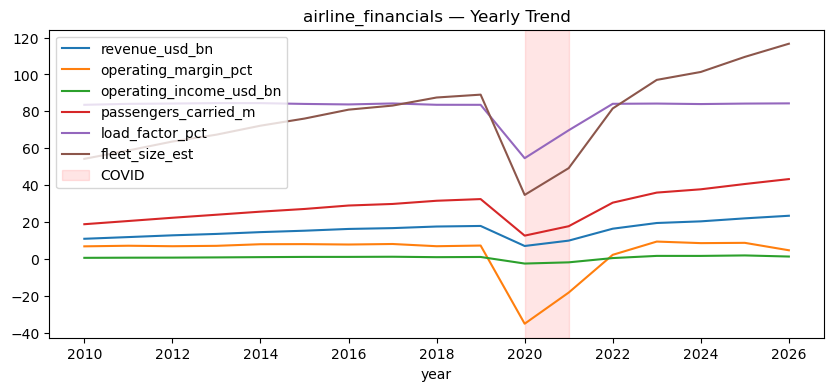

In [22]:
eda_charts(airline_financials, "airline_financials")

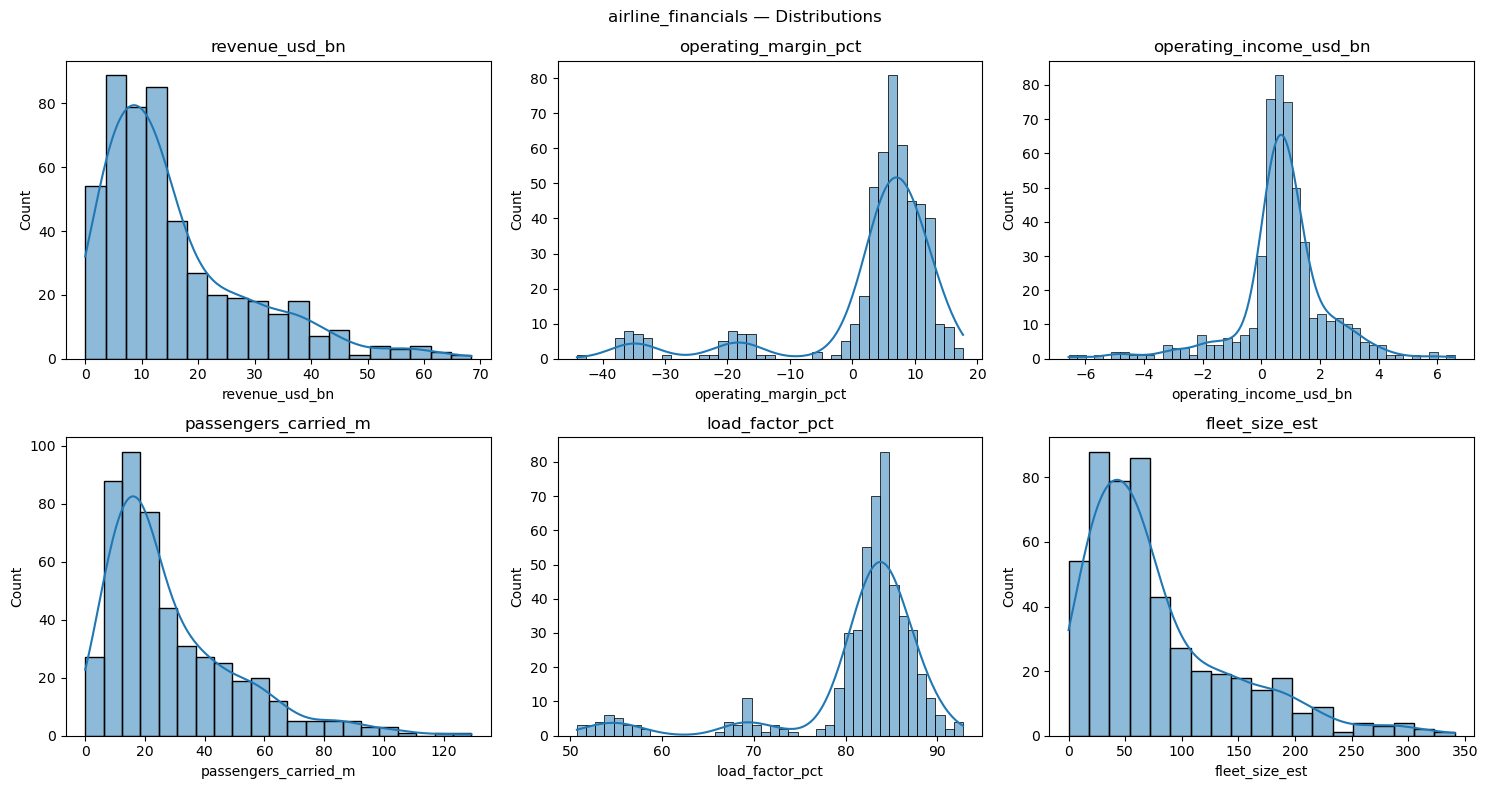

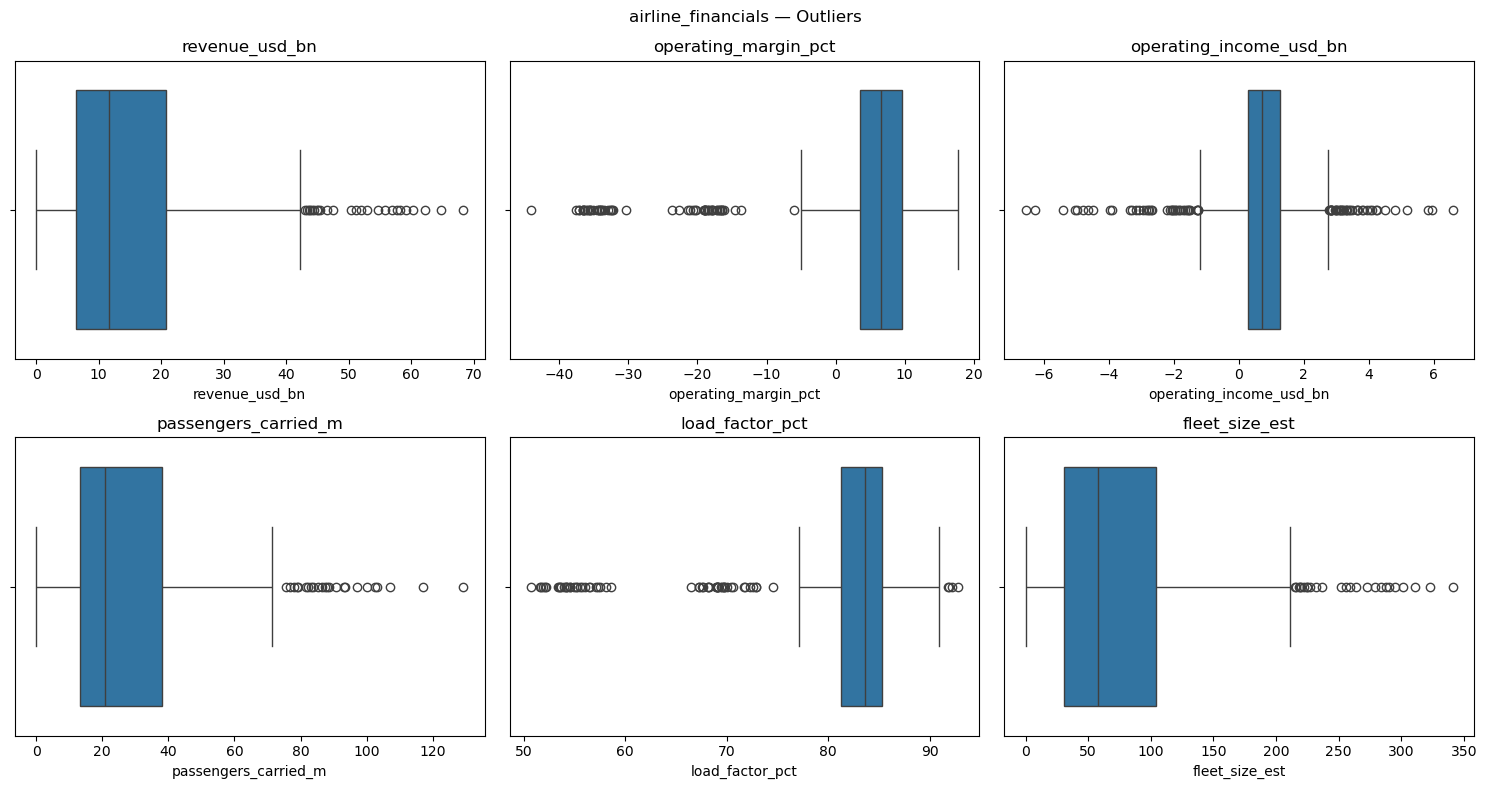

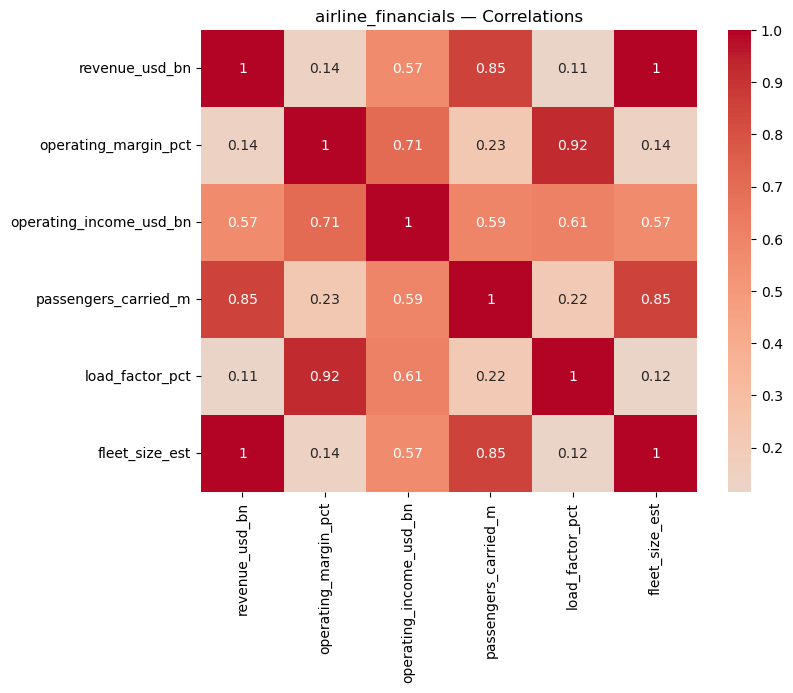

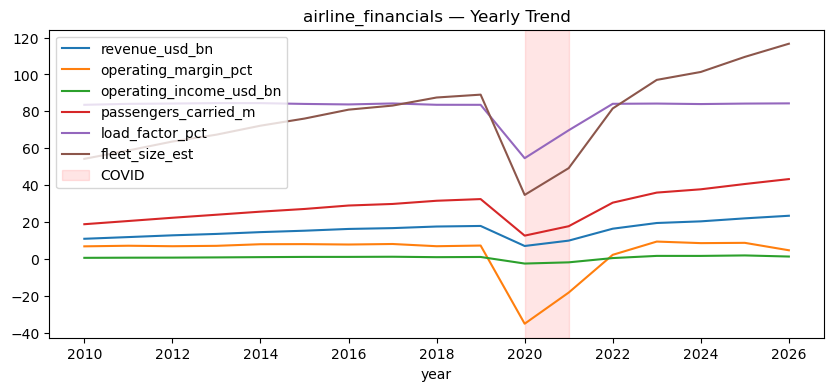

In [23]:
eda_charts(airline_financials, "airline_financials")

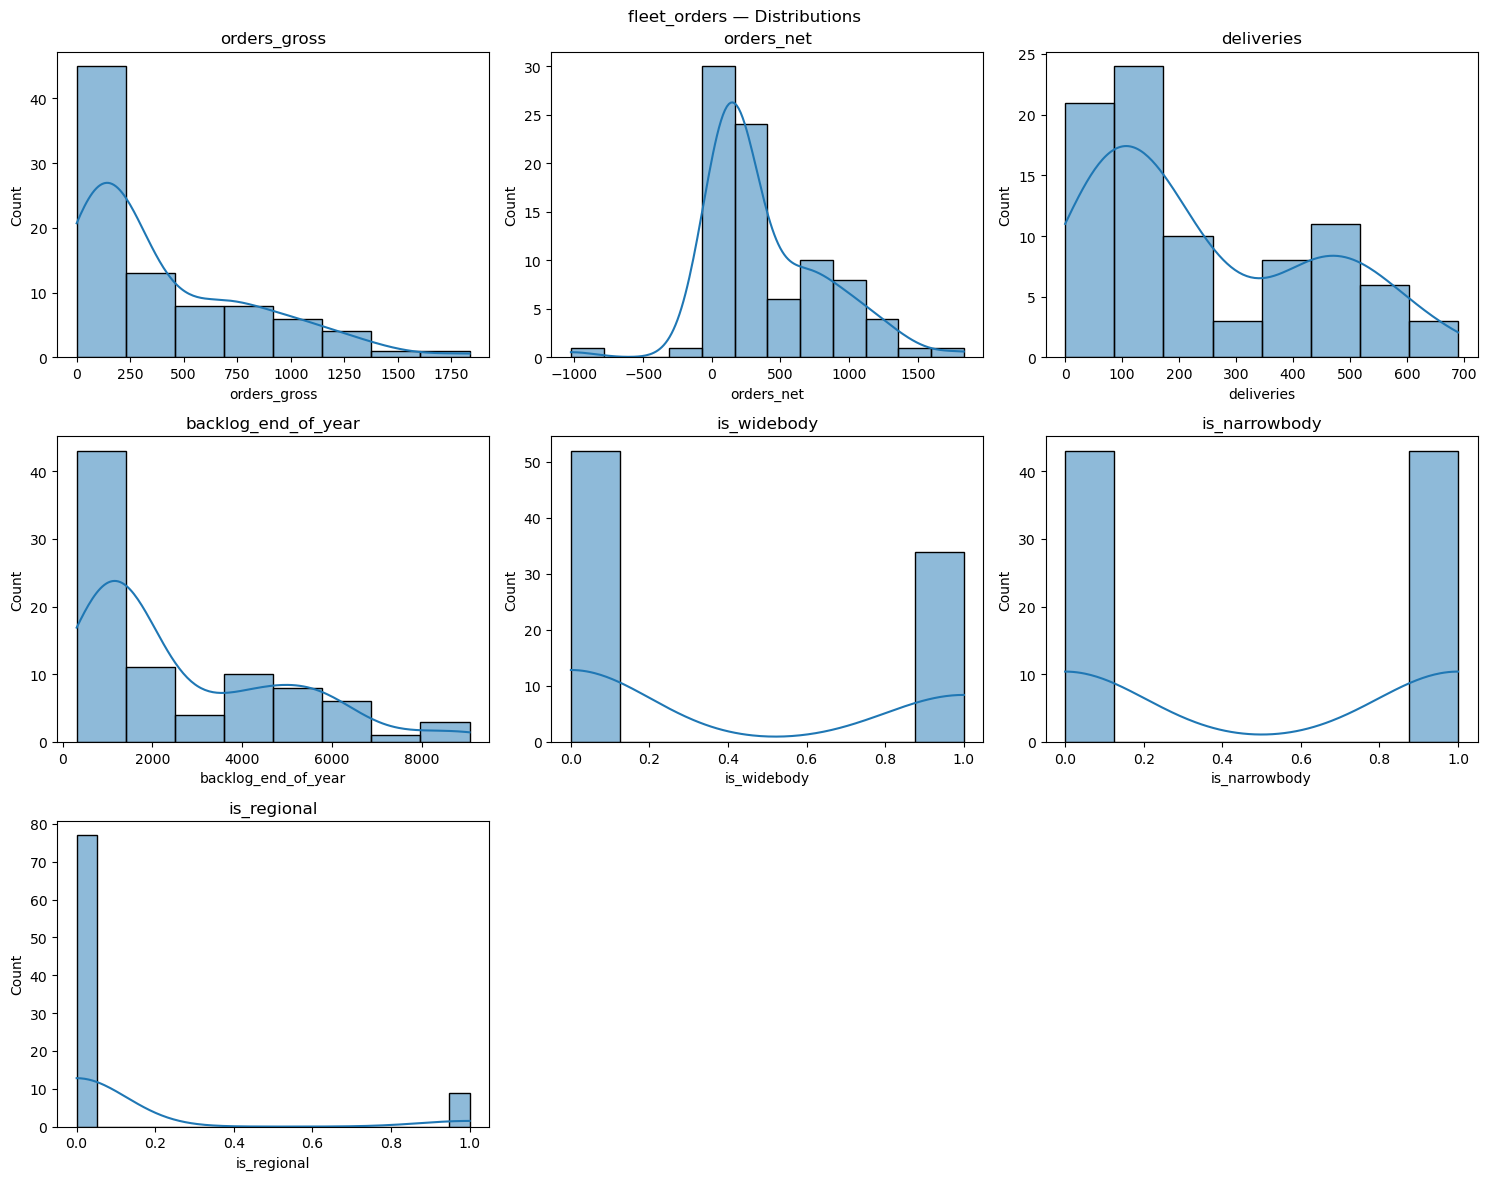

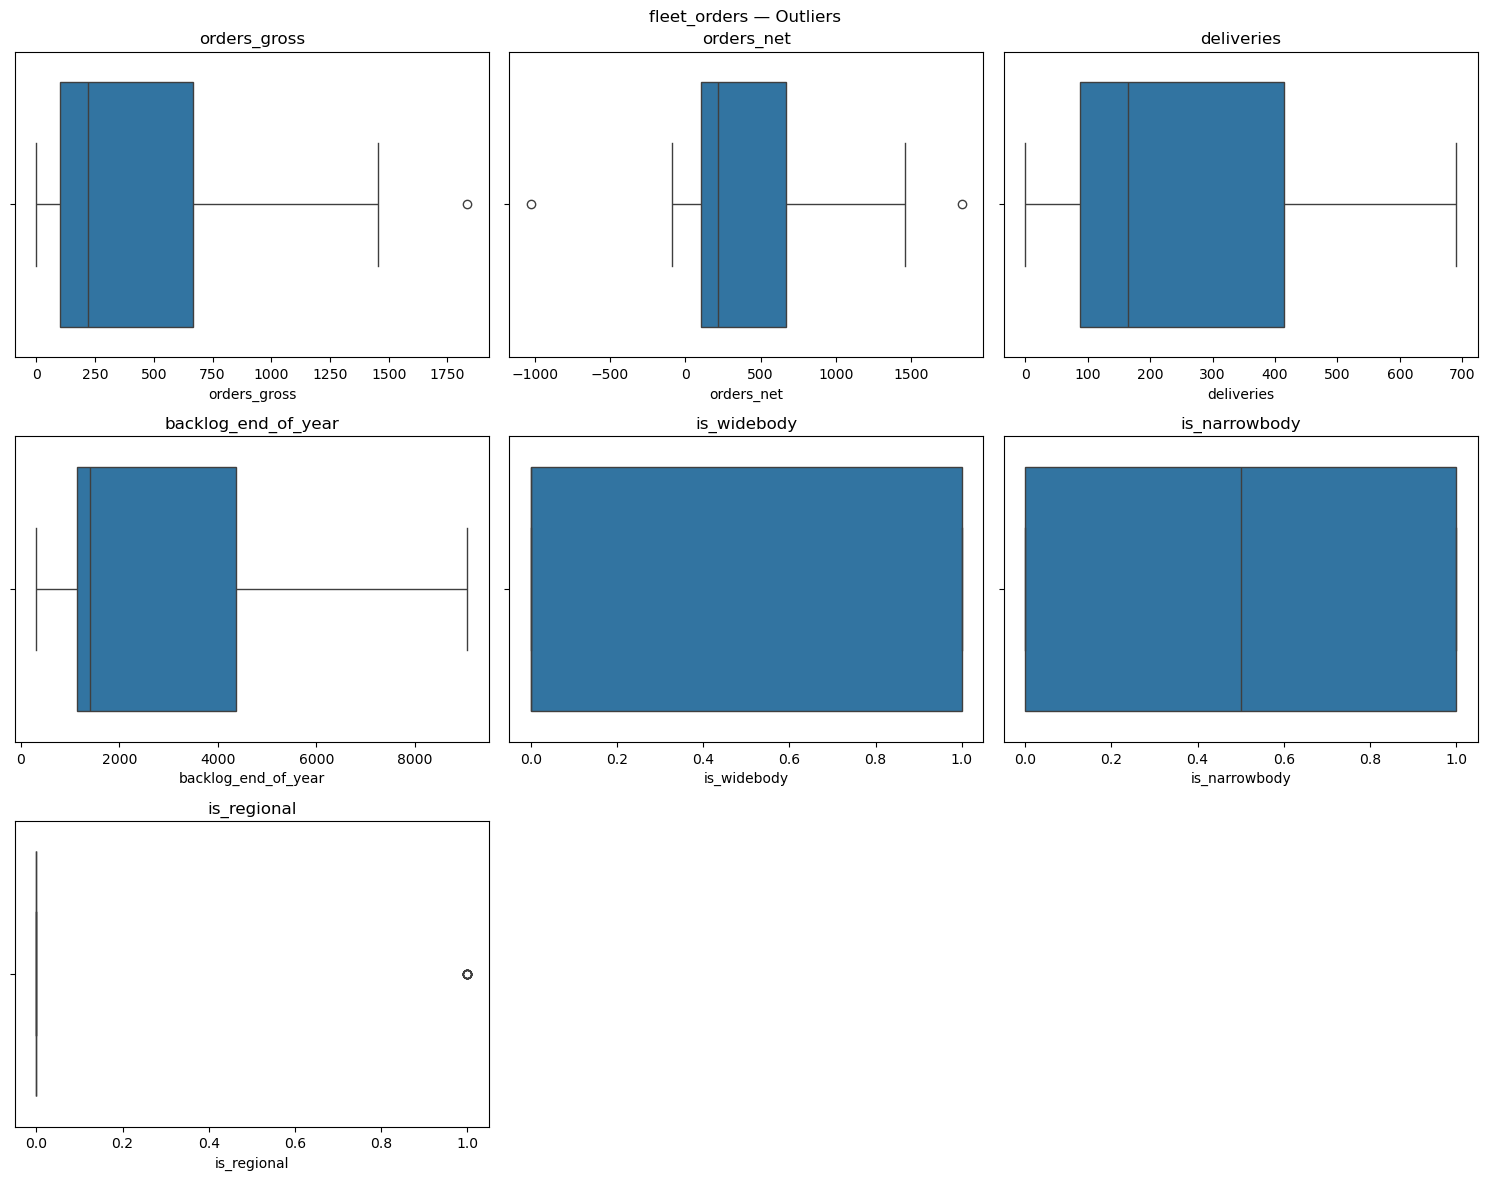

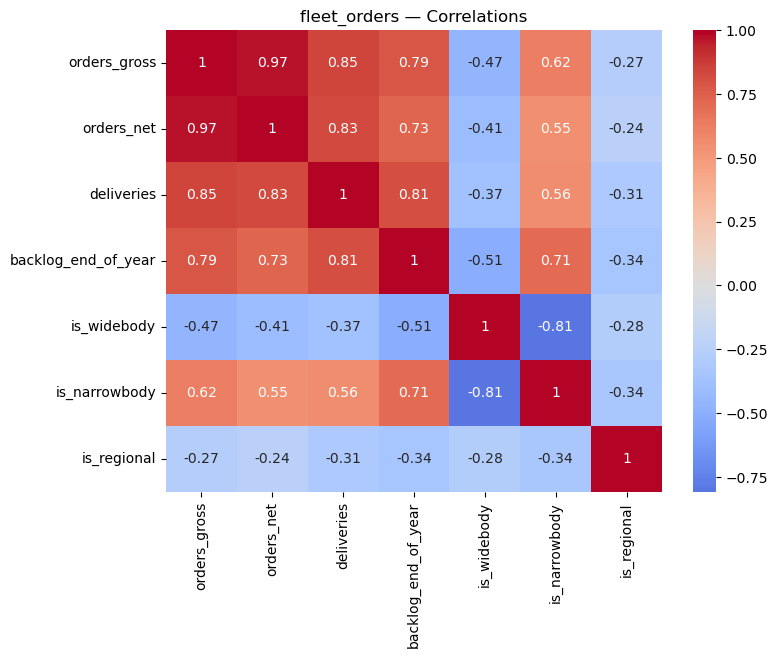

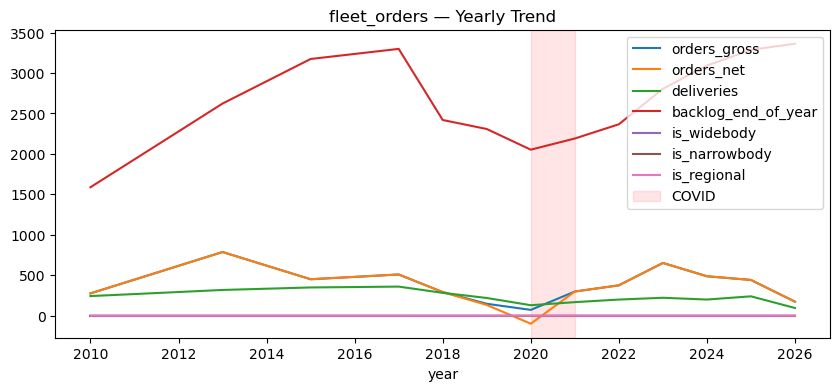

In [24]:
eda_charts(fleet_orders, "fleet_orders")

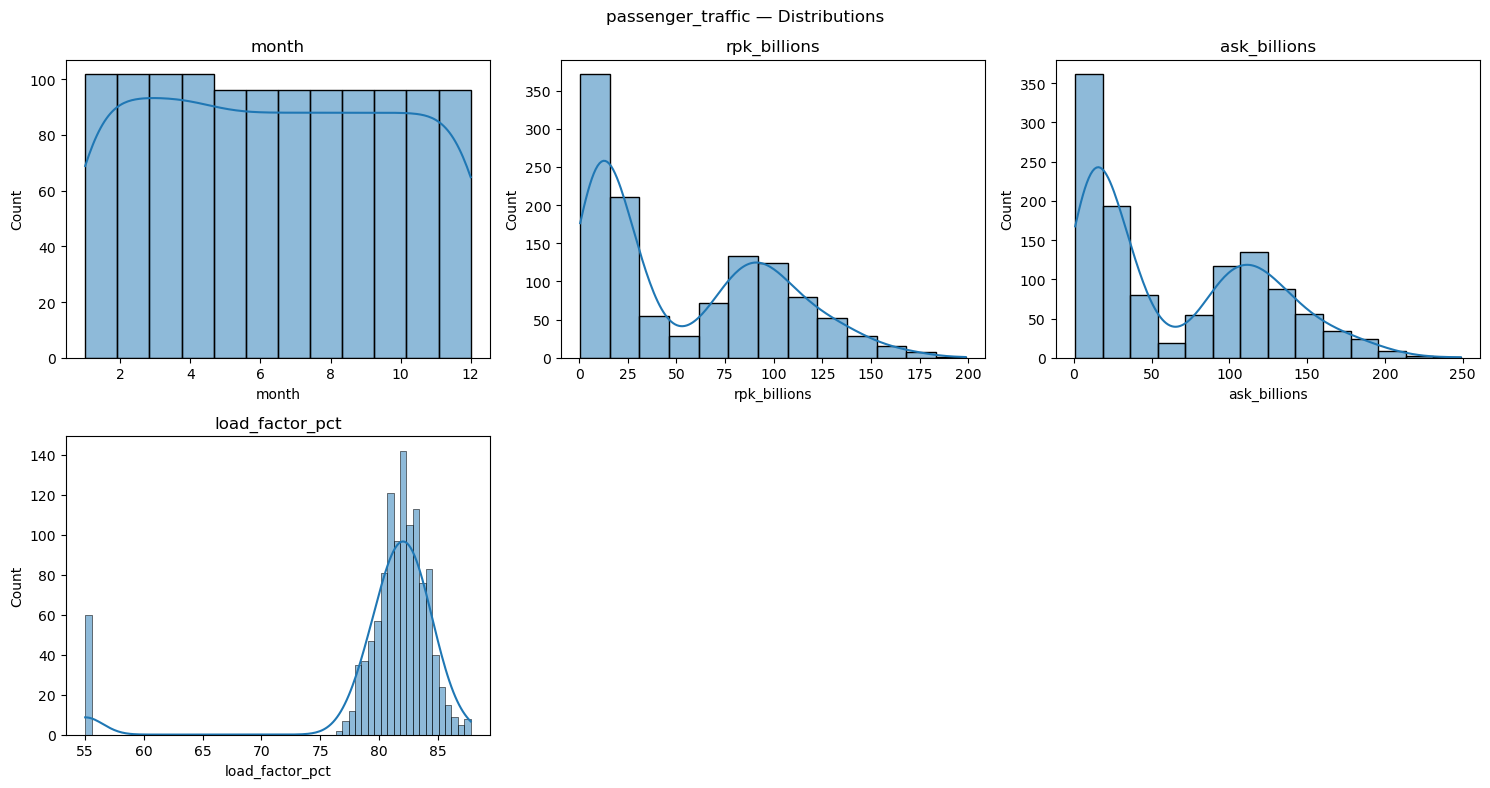

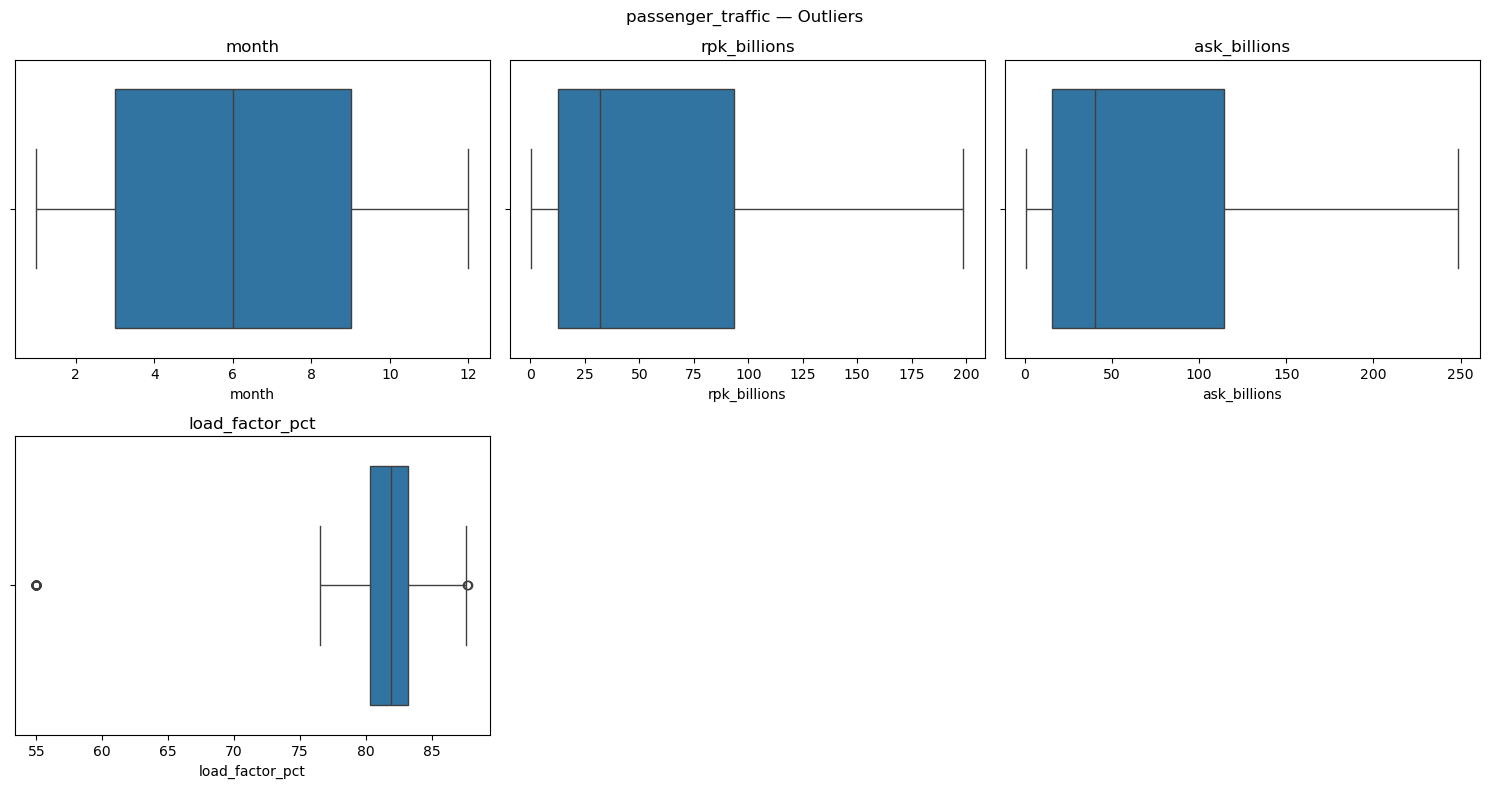

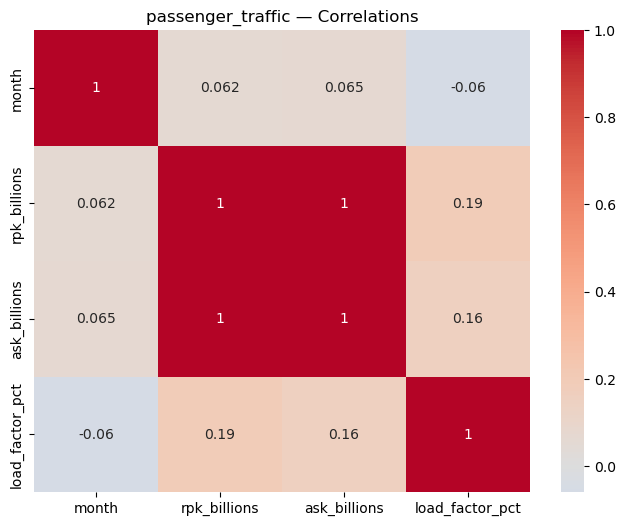

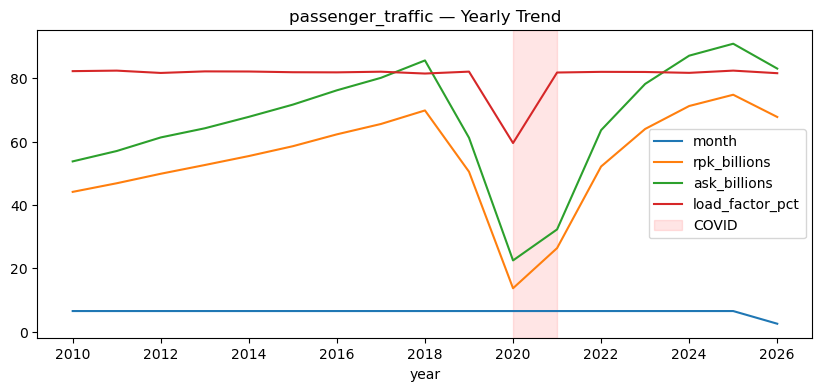

In [25]:
eda_charts(passenger_traffic, "passenger_traffic")

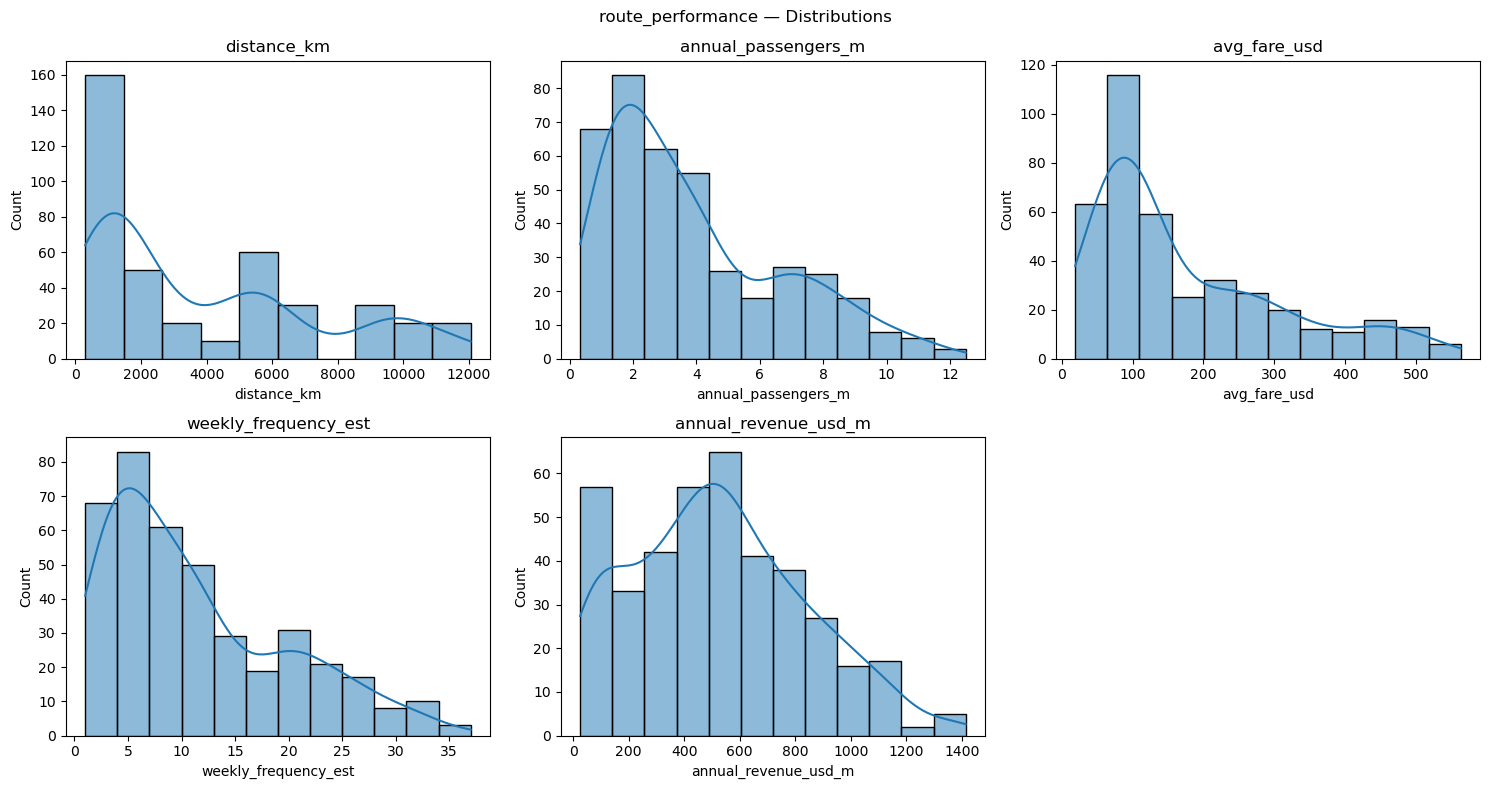

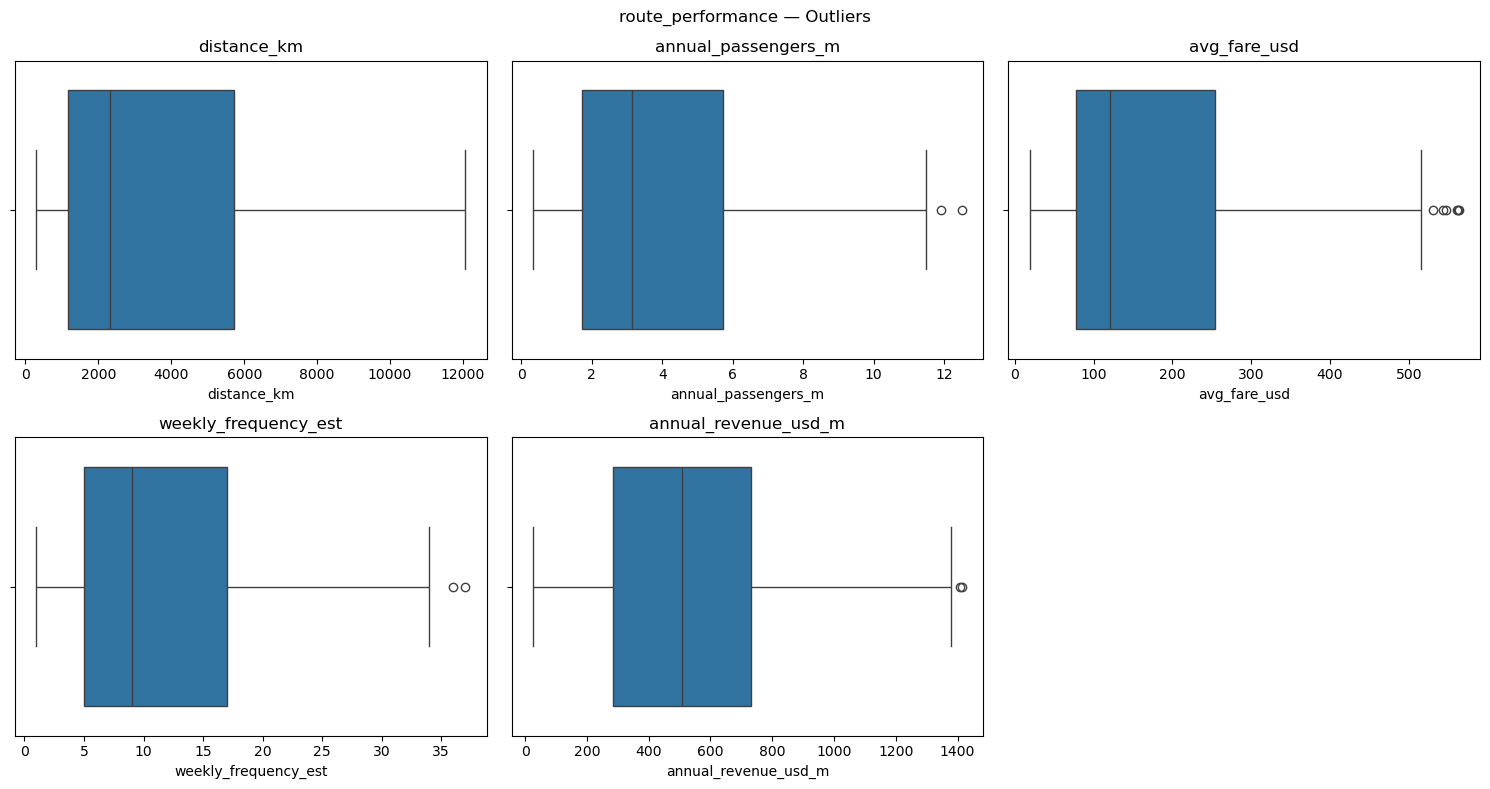

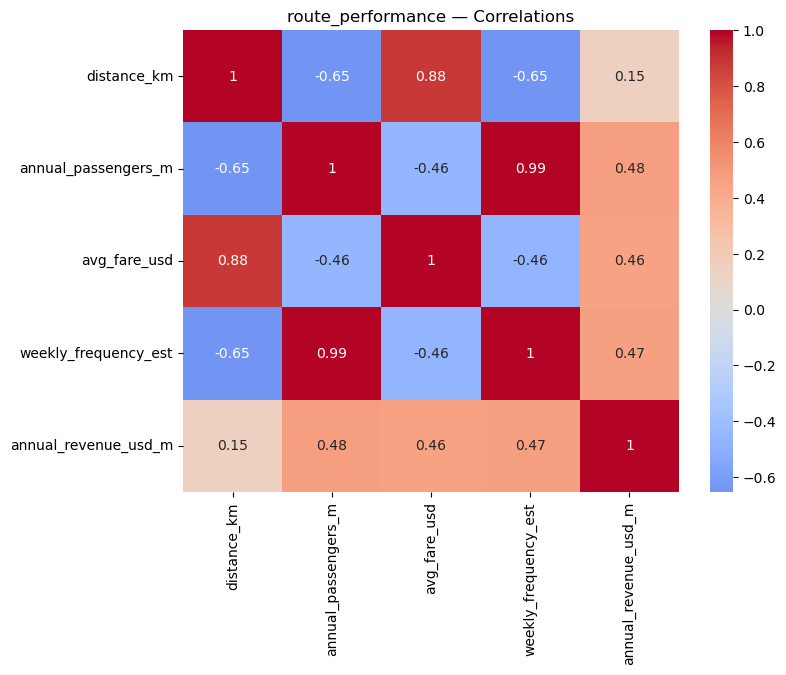

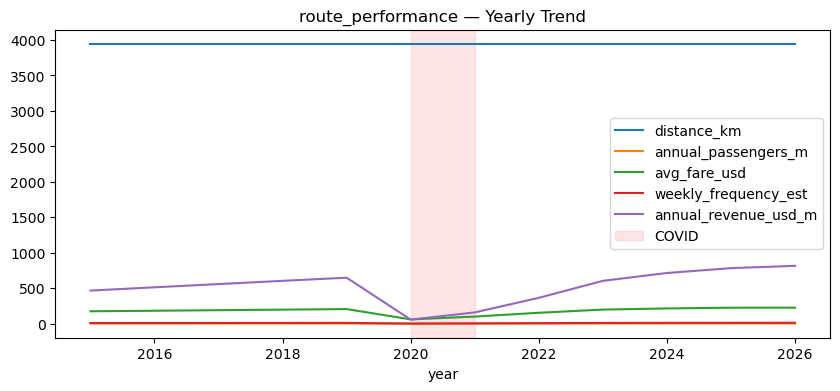

In [26]:
eda_charts(route_performance, "route_performance")

# 4. PreProcessing

### 4.1 Checking for missing values

In [28]:
airline_financials.isna().sum()

year                       0
airline_name               0
iata_code                  0
country_iso3               0
region                     0
business_model             0
revenue_usd_bn             0
operating_margin_pct       0
operating_income_usd_bn    0
passengers_carried_m       0
load_factor_pct            0
fleet_size_est             0
dtype: int64

In [34]:
aviation_incidents.isna().sum()

incident_id        0
date               0
year               0
month              0
flight_number      0
airline            0
aircraft_type      0
severity           0
fatalities         0
location           0
description        0
is_fatal           0
is_geopolitical    0
is_boeing          0
is_airbus          0
dtype: int64

In [35]:
fleet_orders.isna().sum()

year                   0
manufacturer           0
aircraft_family        0
orders_gross           0
orders_net             0
deliveries             0
backlog_end_of_year    0
is_widebody            0
is_narrowbody          0
is_regional            0
dtype: int64

In [36]:
passenger_traffic.isna().sum()

year_month         0
year               0
month              0
region             0
rpk_billions       0
ask_billions       0
load_factor_pct    0
dtype: int64

In [37]:
route_performance.isna().sum()

year                    0
route                   0
origin_iata             0
destination_iata        0
distance_km             0
region                  0
main_airlines           0
annual_passengers_m     0
avg_fare_usd            0
weekly_frequency_est    0
annual_revenue_usd_m    0
dtype: int64

### 4.2 Feature engeneering

In [49]:
route_performance

,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
0,2015,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",6.37,50.0,19,320.5
1,2018,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.92,68.0,22,539.4
2,2019,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.65,65.0,21,498.0
3,2020,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",2.21,21.0,4,45.4
4,2021,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",3.57,34.0,10,121.5
...,...,...,...,...,...,...,...,...,...,...,...
395,2022,New York-Miami,JFK,MIA,1759,North America,"American, Delta, JetBlue",2.51,97.0,7,243.6
396,2023,New York-Miami,JFK,MIA,1759,North America,"American, Delta, JetBlue",3.26,128.0,9,417.9
397,2024,New York-Miami,JFK,MIA,1759,North America,"American, Delta, JetBlue",3.79,127.0,11,480.3
398,2025,New York-Miami,JFK,MIA,1759,North America,"American, Delta, JetBlue",3.79,139.0,10,528.1


In [52]:
route_yearly = route_performance.groupby("year").agg(avg_fare_usd = ("avg_fare_usd","mean"),
                                                    total_route_passengers_m=("annual_passengers_m", "sum"),
                                                    n_routes_reported=("route", "count")).reset_index()

In [60]:
airline_financials = airline_financials.merge(route_yearly, on="year", how="left")

In [55]:
airline_financials.T

,0,1,2,3,4,5,6,7,8,9,...,11750,11751,11752,11753,11754,11755,11756,11757,11758,11759
year,2015,2015,2015,2015,2015,2015,2015,2015,2015,2015,...,2026,2026,2026,2026,2026,2026,2026,2026,2026,2026
airline_name,Delta Air Lines,Delta Air Lines,Delta Air Lines,Delta Air Lines,Delta Air Lines,Delta Air Lines,Delta Air Lines,Delta Air Lines,Delta Air Lines,Delta Air Lines,...,Azul,Azul,Azul,Azul,Azul,Azul,Azul,Azul,Azul,Azul
iata_code,DAL,DAL,DAL,DAL,DAL,DAL,DAL,DAL,DAL,DAL,...,AZUL,AZUL,AZUL,AZUL,AZUL,AZUL,AZUL,AZUL,AZUL,AZUL
country_iso3,USA,USA,USA,USA,USA,USA,USA,USA,USA,USA,...,BRA,BRA,BRA,BRA,BRA,BRA,BRA,BRA,BRA,BRA
region_x,North America,North America,North America,North America,North America,North America,North America,North America,North America,North America,...,Latin America,Latin America,Latin America,Latin America,Latin America,Latin America,Latin America,Latin America,Latin America,Latin America
business_model,legacy,legacy,legacy,legacy,legacy,legacy,legacy,legacy,legacy,legacy,...,low_cost,low_cost,low_cost,low_cost,low_cost,low_cost,low_cost,low_cost,low_cost,low_cost
revenue_usd_bn,39.66,39.66,39.66,39.66,39.66,39.66,39.66,39.66,39.66,39.66,...,4.85,4.85,4.85,4.85,4.85,4.85,4.85,4.85,4.85,4.85
operating_margin_pct,6.9,6.9,6.9,6.9,6.9,6.9,6.9,6.9,6.9,6.9,...,12.4,12.4,12.4,12.4,12.4,12.4,12.4,12.4,12.4,12.4
operating_income_usd_bn,2.75,2.75,2.75,2.75,2.75,2.75,2.75,2.75,2.75,2.75,...,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
passengers_carried_m,59.5,59.5,59.5,59.5,59.5,59.5,59.5,59.5,59.5,59.5,...,19.4,19.4,19.4,19.4,19.4,19.4,19.4,19.4,19.4,19.4


In [64]:
airline_financials = airline_financials.rename(columns={
    "avg_fare_usd": "industry_avg_fare_usd",
    "total_route_passengers_m": "industry_total_route_passengers_m",
    "n_routes_reported": "industry_n_routes_reported"})

# 4.3 Column Transformer

In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [66]:
airline_financials.dtypes

year                                   int64
airline_name                          object
iata_code                             object
country_iso3                          object
region_x                              object
business_model                        object
revenue_usd_bn                       float64
operating_margin_pct                 float64
operating_income_usd_bn              float64
passengers_carried_m                 float64
load_factor_pct                      float64
fleet_size_est                         int64
route                                 object
origin_iata                           object
destination_iata                      object
distance_km                            int64
region_y                              object
main_airlines                         object
annual_passengers_m                  float64
avg_fare_usd_x                       float64
weekly_frequency_est                   int64
annual_revenue_usd_m                 float64
avg_fare_u

In [71]:
obj_cols = airline_financials.select_dtypes(include="object").columns.tolist()
numeric_cols = airline_financials.select_dtypes(include="number").columns.tolist()

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), obj_col),
    ("num", StandardScaler(), numeric_cols),
])